# Huấn Luyện Mô Hình - Pima Indians Diabetes

**Bài toán:** Phân loại nhị phân — dự đoán khả năng mắc bệnh tiểu đường.

**Mục tiêu notebook này:**
- So sánh nhiều thuật toán phân loại ở mức baseline (tham số mặc định) trên 3 phiên bản chuẩn hoá khác nhau.
- Tinh chỉnh siêu tham số (GridSearchCV) cho các mô hình tiềm năng.
- Lựa chọn mô hình tốt nhất dựa trên chỉ số tổng hợp, lưu toàn bộ mô hình và ghi log.

**Đầu vào:** Các file CSV được tạo từ `01_eda.ipynb` trong thư mục `exps_/pima_indians_diabetes/`.


## Bước 5: Khởi Tạo Thực Nghiệm

Cấu hình đường dẫn, danh sách mô hình ứng viên và lưới siêu tham số cho bước tuning.

**Chỉ số tổng hợp (Composite)** được định nghĩa là: `0.4 × Accuracy + 0.3 × F1 + 0.3 × ROC-AUC`.
Trọng số này ưu tiên Accuracy nhưng vẫn phạt nặng nếu mô hình kém trên lớp thiểu số (F1) hoặc kém phân biệt tổng thể (AUC).


In [1]:
import os, pickle, time, warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (AdaBoostClassifier, ExtraTreesClassifier,
                               GradientBoostingClassifier, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Đường dẫn — phải khớp với cấu hình trong 01_eda.ipynb ─────────────────
DATA_NAME = 'pima_indians_diabetes'
BASE_DIR  = (
    os.path.abspath(os.path.join(os.getcwd(), '..'))
    if os.path.basename(os.getcwd()) == 'prj'
    else os.getcwd()
)
EXP_DIR   = os.path.join(BASE_DIR, 'exps_', DATA_NAME)
MODEL_DIR = os.path.join(BASE_DIR, 'model', DATA_NAME)
os.makedirs(MODEL_DIR, exist_ok=True)

TRAIN_LOG       = os.path.join(EXP_DIR, 'train_log.xlsx')
BEST_MODEL_PATH = os.path.join(MODEL_DIR, f'{DATA_NAME}__best_model.pkl')

FILES = {
    'raw':      (os.path.join(EXP_DIR, 'train_raw.csv'),      os.path.join(EXP_DIR, 'test_raw.csv')),
    'minmax':   (os.path.join(EXP_DIR, 'train_minmax.csv'),   os.path.join(EXP_DIR, 'test_minmax.csv')),
    'standard': (os.path.join(EXP_DIR, 'train_standard.csv'), os.path.join(EXP_DIR, 'test_standard.csv')),
}

# ── Siêu tham số thực nghiệm ───────────────────────────────────────────────
RANDOM_STATE = 42
N_SPLITS     = 5
N_JOBS       = -1   # Dùng toàn bộ CPU core — tăng tốc CV và GridSearch đáng kể

COMPOSITE_WEIGHTS = {'Accuracy': 0.4, 'F1': 0.3, 'ROC_AUC': 0.3}

# Dùng cross_validate để tính đồng thời nhiều metric trong 1 lần chạy CV
# thay vì gọi cross_val_score riêng lẻ từng metric (tránh fit lặp 3 lần/model)
SCORING = {'Accuracy': 'accuracy', 'F1': 'f1', 'ROC_AUC': 'roc_auc'}

# Lưới tham số — thu gọn để tăng tốc, vẫn bao phủ các vùng tham số quan trọng
PARAM_GRIDS = {
    'SVM':           {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']},
    'Random Forest': {'n_estimators': [100, 200], 'max_depth': [None, 5, 10]},
    'kNN':           {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']},
}


def load_data(train_path, test_path):
    """Đọc file CSV và tách X, y cho cả tập train và test.
    Quy ước: cột cuối cùng là nhãn (class), các cột còn lại là đặc trưng.
    """
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)
    return (
        train_df, test_df,
        train_df.iloc[:, :-1].values, train_df.iloc[:, -1].values,
        test_df.iloc[:, :-1].values,  test_df.iloc[:, -1].values,
    )


def get_candidate_models():
    """Trả về danh sách (tên, estimator) của tất cả mô hình ứng viên.
    n_estimators giữ ở mức vừa đủ để kết quả ổn định mà không quá chậm.
    Mỗi lần gọi tạo instance mới để tránh chia sẻ trạng thái giữa các lần chạy.
    """
    return [
        ('kNN',                 KNeighborsClassifier(n_jobs=N_JOBS)),
        ('Naive Bayes',         GaussianNB()),
        ('SVM',                 SVC(probability=True, random_state=RANDOM_STATE)),
        ('Decision Tree',       DecisionTreeClassifier(random_state=RANDOM_STATE)),
        ('Random Forest',       RandomForestClassifier(n_estimators=100, n_jobs=N_JOBS,
                                                       random_state=RANDOM_STATE)),
        ('AdaBoost',            AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)),
        ('Gradient Boosting',   GradientBoostingClassifier(n_estimators=100,
                                                           random_state=RANDOM_STATE)),
        ('Extra Trees',         ExtraTreesClassifier(n_estimators=100, n_jobs=N_JOBS,
                                                     random_state=RANDOM_STATE)),
        ('LDA',                 LinearDiscriminantAnalysis()),
        ('MLP',                 MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                              random_state=RANDOM_STATE)),
        ('Logistic Regression', LogisticRegression(max_iter=500, n_jobs=N_JOBS,
                                                   random_state=RANDOM_STATE)),
    ]


# Kiểm tra nhanh kích thước dữ liệu sau khi load
for scaler_name, (train_path, test_path) in FILES.items():
    _, _, X_train, y_train, X_test, y_test = load_data(train_path, test_path)
    print(f'[{scaler_name:8s}] Train: {X_train.shape} | Test: {X_test.shape} | Classes: {np.unique(y_train)}')


[raw     ] Train: (537, 8) | Test: (231, 8) | Classes: [0 1]
[minmax  ] Train: (537, 8) | Test: (231, 8) | Classes: [0 1]
[standard] Train: (537, 8) | Test: (231, 8) | Classes: [0 1]


## Bước 6: Đánh Giá Baseline bằng Cross-Validation

Chạy `StratifiedKFold` (5 fold) để đánh giá tất cả mô hình ứng viên với tham số mặc định trên cả 3 phiên bản chuẩn hoá.

Stratified fold đảm bảo tỉ lệ lớp được giữ nguyên trong mỗi fold — quan trọng khi dữ liệu mất cân bằng.
Kết quả baseline giúp loại bỏ sớm các mô hình yếu và xác định ứng viên cho bước tuning.


In [2]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

print(f'Bắt đầu baseline: {len(list(FILES))} scaler × {len(get_candidate_models())} model × {N_SPLITS} fold...')
t0 = time.time()

base_rows = []
for scaler_name, (train_path, _) in FILES.items():
    _, _, X_train, y_train, _, _ = load_data(train_path, train_path)
    for model_name, model in get_candidate_models():
        cv_results = cross_validate(
            model, X_train, y_train,
            cv=skf, scoring=SCORING,
            n_jobs=N_JOBS, return_train_score=False
        )
        row = {
            'Scaler':   scaler_name,
            'Model':    model_name,
            'Loại':     'Baseline',
            'Accuracy': round(float(cv_results['test_Accuracy'].mean()), 4),
            'Acc Std':  round(float(cv_results['test_Accuracy'].std()),  4),
            'F1':       round(float(cv_results['test_F1'].mean()),       4),
            'F1 Std':   round(float(cv_results['test_F1'].std()),        4),
            'ROC_AUC':  round(float(cv_results['test_ROC_AUC'].mean()),  4),
            'AUC Std':  round(float(cv_results['test_ROC_AUC'].std()),   4),
            'Params':   'default',
        }
        row['Composite'] = round(
            COMPOSITE_WEIGHTS['Accuracy'] * row['Accuracy']
            + COMPOSITE_WEIGHTS['F1']       * row['F1']
            + COMPOSITE_WEIGHTS['ROC_AUC']  * row['ROC_AUC'],
            4
        )
        base_rows.append(row)
        print(f'  [{scaler_name:8s}] {model_name:22s} → Composite: {row["Composite"]:.4f}')

elapsed = time.time() - t0
print(f'\nHoàn thành baseline trong {elapsed:.1f}s')

df_baseline = (
    pd.DataFrame(base_rows)
    .sort_values(['Composite', 'Accuracy', 'F1'], ascending=False)
    .reset_index(drop=True)
)
display(df_baseline.head(15))


Bắt đầu baseline: 3 scaler × 11 model × 5 fold...
  [raw     ] kNN                    → Composite: 0.6789
  [raw     ] Naive Bayes            → Composite: 0.7352
  [raw     ] SVM                    → Composite: 0.7145
  [raw     ] Decision Tree          → Composite: 0.6060
  [raw     ] Random Forest          → Composite: 0.7402
  [raw     ] AdaBoost               → Composite: 0.7437
  [raw     ] Gradient Boosting      → Composite: 0.7288
  [raw     ] Extra Trees            → Composite: 0.7523
  [raw     ] LDA                    → Composite: 0.7518
  [raw     ] MLP                    → Composite: 0.5940
  [raw     ] Logistic Regression    → Composite: 0.7549
  [minmax  ] kNN                    → Composite: 0.7112
  [minmax  ] Naive Bayes            → Composite: 0.7352
  [minmax  ] SVM                    → Composite: 0.7602
  [minmax  ] Decision Tree          → Composite: 0.6032
  [minmax  ] Random Forest          → Composite: 0.7388
  [minmax  ] AdaBoost               → Composite: 0.743

,Scaler,Model,Loại,Accuracy,Acc Std,F1,F1 Std,ROC_AUC,AUC Std,Params,Composite
0,minmax,MLP,Baseline,0.7953,0.0476,0.6857,0.0596,0.8270,0.0438,default,0.7719
1,minmax,SVM,Baseline,0.7860,0.0447,0.6546,0.0712,0.8315,0.0403,default,0.7602
2,standard,Logistic Regression,Baseline,0.7841,0.0278,0.6505,0.0495,0.8241,0.0377,default,0.7560
3,raw,Logistic Regression,Baseline,0.7822,0.0280,0.6487,0.0484,0.8247,0.0371,default,0.7549
4,raw,Extra Trees,Baseline,0.7822,0.0298,0.6428,0.0541,0.8219,0.0296,default,0.7523
5,minmax,Extra Trees,Baseline,0.7822,0.0298,0.6428,0.0541,0.8219,0.0296,default,0.7523
6,standard,Extra Trees,Baseline,0.7822,0.0298,0.6428,0.0541,0.8219,0.0296,default,0.7523
7,raw,LDA,Baseline,0.7803,0.0254,0.6421,0.0483,0.8235,0.0350,default,0.7518
8,minmax,LDA,Baseline,0.7803,0.0254,0.6421,0.0483,0.8235,0.0350,default,0.7518
9,standard,LDA,Baseline,0.7803,0.0254,0.6421,0.0483,0.8235,0.0350,default,0.7518


## Bước 7: Đánh Giá và Tinh Chỉnh Thuật Toán


### 7.1. Biểu Đồ Baseline — So Sánh Các Mô Hình Mặc Định

Trực quan hoá Composite score của tất cả mô hình baseline, phân theo phương pháp chuẩn hoá.
Nhìn vào 3 biểu đồ này để xác định xem chuẩn hoá nào đang giúp ích nhiều nhất cho các mô hình tuyến tính so với các mô hình phi tuyến.


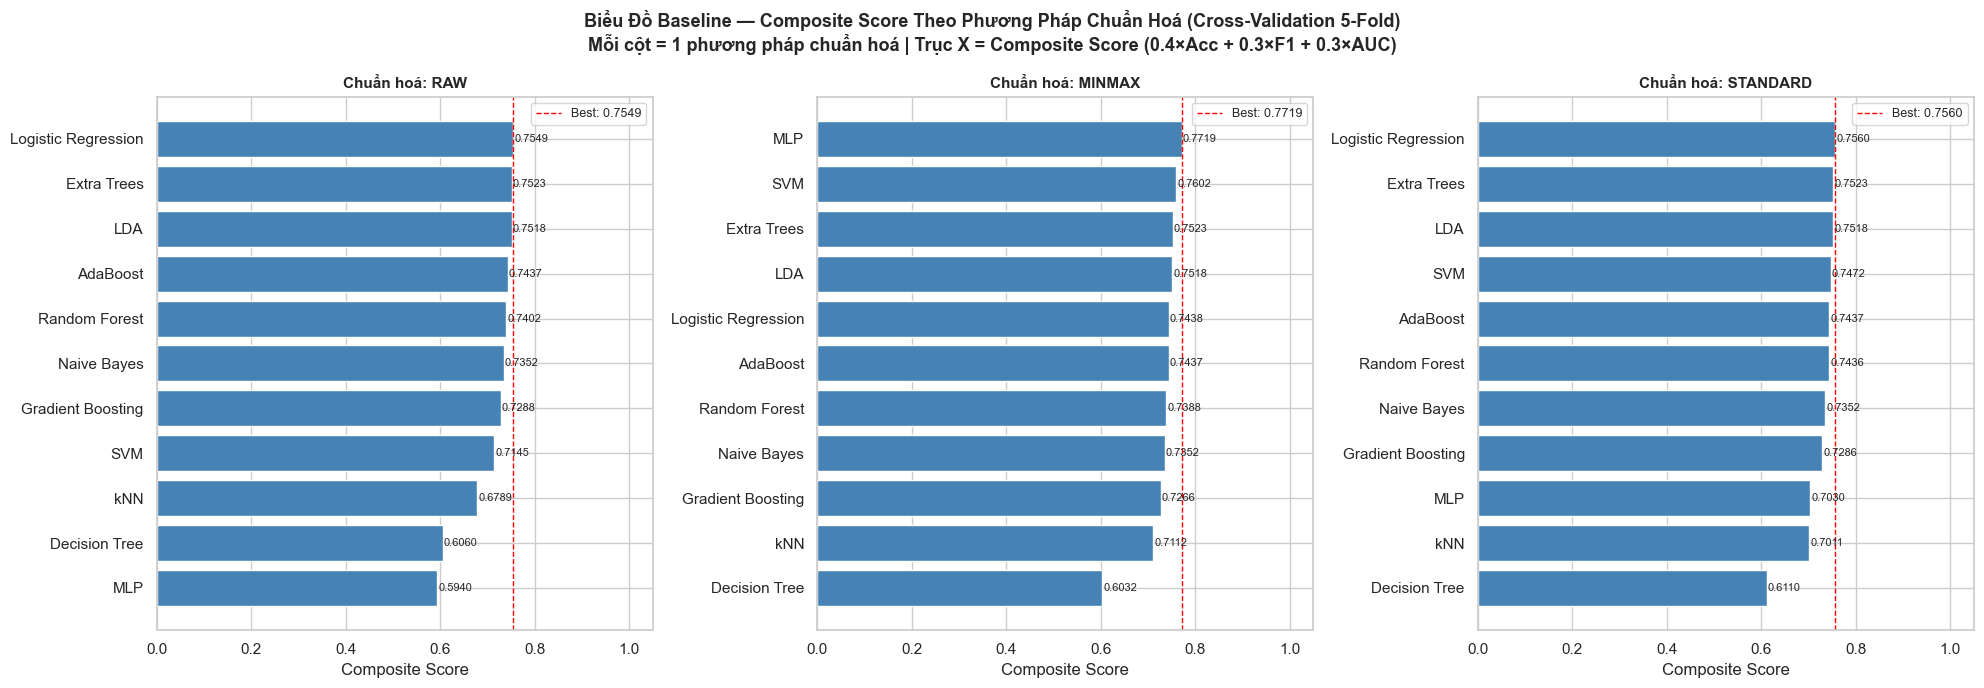

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True)
fig.suptitle(
    'Biểu Đồ Baseline — Composite Score Theo Phương Pháp Chuẩn Hoá (Cross-Validation 5-Fold)\n'
    'Mỗi cột = 1 phương pháp chuẩn hoá | Trục X = Composite Score (0.4×Acc + 0.3×F1 + 0.3×AUC)',
    fontsize=13, fontweight='bold'
)
for i, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_baseline[df_baseline['Scaler'] == scaler_name].sort_values('Composite')
    bars = axes[i].barh(subset['Model'], subset['Composite'], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Chuẩn hoá: {scaler_name.upper()}', fontsize=11, fontweight='bold')
    axes[i].set_xlim(0.0, 1.05)
    axes[i].set_xlabel('Composite Score')
    axes[i].axvline(subset['Composite'].max(), color='red', linestyle='--', linewidth=1,
                    label=f'Best: {subset["Composite"].max():.4f}')
    axes[i].legend(fontsize=9)
    # Ghi giá trị lên từng thanh
    for bar, val in zip(bars, subset['Composite']):
        axes[i].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                     f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_baseline.png'), bbox_inches='tight')
plt.show()


### 7.2. Tinh Chỉnh Siêu Tham Số (GridSearchCV)

Chạy GridSearchCV cho 3 mô hình được chọn: SVM, Random Forest và kNN.
Tìm kiếm vét cạn trên lưới tham số đã định nghĩa, tối ưu theo Accuracy trong cross-validation.

**Lưu ý:** `best_estimator_` từ GridSearchCV đã được fit trên toàn bộ tập train sau khi tìm ra tham số tốt nhất — không cần fit lại ở bước sau.


In [4]:
base_lookup = {name: model for name, model in get_candidate_models()}

tuned_rows      = []
best_estimators = {}

print(f'Bắt đầu GridSearchCV: {len(PARAM_GRIDS)} model × {len(FILES)} scaler...')
t0 = time.time()

for scaler_name, (train_path, _) in FILES.items():
    _, _, X_train, y_train, _, _ = load_data(train_path, train_path)
    best_estimators[scaler_name] = {}

    for model_name, params in PARAM_GRIDS.items():
        n_combos = 1
        for v in params.values():
            n_combos *= len(v)
        print(f'  [{scaler_name:8s}] {model_name:15s} — {n_combos} tổ hợp × {N_SPLITS} fold...', end=' ')
        t1 = time.time()

        grid = GridSearchCV(
            base_lookup[model_name], params,
            cv=skf, scoring='accuracy',
            refit=True, n_jobs=N_JOBS
        )
        grid.fit(X_train, y_train)
        best_estimators[scaler_name][model_name] = grid.best_estimator_

        cv_res = cross_validate(
            grid.best_estimator_, X_train, y_train,
            cv=skf, scoring=SCORING,
            n_jobs=N_JOBS, return_train_score=False
        )
        tuned_row = {
            'Scaler':   scaler_name,
            'Model':    f'{model_name} (tuned)',
            'Loại':     'Tuned',
            'Accuracy': round(float(cv_res['test_Accuracy'].mean()), 4),
            'Acc Std':  round(float(cv_res['test_Accuracy'].std()),  4),
            'F1':       round(float(cv_res['test_F1'].mean()),       4),
            'F1 Std':   round(float(cv_res['test_F1'].std()),        4),
            'ROC_AUC':  round(float(cv_res['test_ROC_AUC'].mean()),  4),
            'AUC Std':  round(float(cv_res['test_ROC_AUC'].std()),   4),
            'Params':   str(grid.best_params_),
        }
        tuned_row['Composite'] = round(
            COMPOSITE_WEIGHTS['Accuracy'] * tuned_row['Accuracy']
            + COMPOSITE_WEIGHTS['F1']       * tuned_row['F1']
            + COMPOSITE_WEIGHTS['ROC_AUC']  * tuned_row['ROC_AUC'],
            4
        )
        tuned_rows.append(tuned_row)
        print(f'done ({time.time()-t1:.1f}s) → Composite: {tuned_row["Composite"]:.4f}')

elapsed = time.time() - t0
print(f'\nHoàn thành tuning trong {elapsed:.1f}s')

df_tuned = pd.DataFrame(tuned_rows)
df_all = (
    pd.concat([df_baseline, df_tuned], ignore_index=True, sort=False)
    .sort_values(['Composite', 'Accuracy'], ascending=False)
    .reset_index(drop=True)
)
display(df_tuned)


Bắt đầu GridSearchCV: 3 model × 3 scaler...
done (91.5s) → Composite: 0.7605 tổ hợp × 5 fold... 
done (1.9s) → Composite: 0.75006 tổ hợp × 5 fold... 
  [raw     ] kNN             — 8 tổ hợp × 5 fold... done (0.2s) → Composite: 0.6970
done (0.3s) → Composite: 0.76026 tổ hợp × 5 fold... 
done (2.1s) → Composite: 0.74676 tổ hợp × 5 fold... 
  [minmax  ] kNN             — 8 tổ hợp × 5 fold... done (0.2s) → Composite: 0.7234
done (0.3s) → Composite: 0.76126 tổ hợp × 5 fold... 
done (2.4s) → Composite: 0.74986 tổ hợp × 5 fold... 
  [standard] kNN             — 8 tổ hợp × 5 fold... done (0.2s) → Composite: 0.7162

Hoàn thành tuning trong 99.0s


,Scaler,Model,Loại,Accuracy,Acc Std,F1,F1 Std,ROC_AUC,AUC Std,Params,Composite
0,raw,SVM (tuned),Tuned,0.7896,0.0321,0.6582,0.0450,0.8240,0.0383,"{'C': 0.1, 'kernel': 'linear'}",0.7605
1,raw,Random Forest (tuned),Tuned,0.7767,0.0378,0.6515,0.0716,0.8129,0.0386,"{'max_depth': None, 'n_estimators': 200}",0.7500
2,raw,kNN (tuned),Tuned,0.7374,0.0158,0.5736,0.0262,0.7665,0.0076,"{'n_neighbors': 9, 'weights': 'distance'}",0.6970
3,minmax,SVM (tuned),Tuned,0.7860,0.0447,0.6546,0.0712,0.8315,0.0403,"{'C': 1, 'kernel': 'rbf'}",0.7602
4,minmax,Random Forest (tuned),Tuned,0.7729,0.0380,0.6464,0.0683,0.8121,0.0394,"{'max_depth': None, 'n_estimators': 200}",0.7467
5,minmax,kNN (tuned),Tuned,0.7580,0.0353,0.6006,0.0559,0.8001,0.0192,"{'n_neighbors': 9, 'weights': 'uniform'}",0.7234
6,standard,SVM (tuned),Tuned,0.7896,0.0287,0.6594,0.0436,0.8251,0.0397,"{'C': 1, 'kernel': 'linear'}",0.7612
7,standard,Random Forest (tuned),Tuned,0.7767,0.0378,0.6515,0.0716,0.8124,0.0396,"{'max_depth': None, 'n_estimators': 200}",0.7498
8,standard,kNN (tuned),Tuned,0.7525,0.0347,0.6077,0.0502,0.7763,0.0157,"{'n_neighbors': 7, 'weights': 'distance'}",0.7162


### 7.3. So Sánh Baseline và Tuned Model

Biểu đồ tổng hợp Top-8 mô hình (bao gồm cả baseline và tuned) theo từng phương pháp chuẩn hoá.
Nhìn vào đây để đánh giá việc tuning có cải thiện đáng kể so với mặc định không.


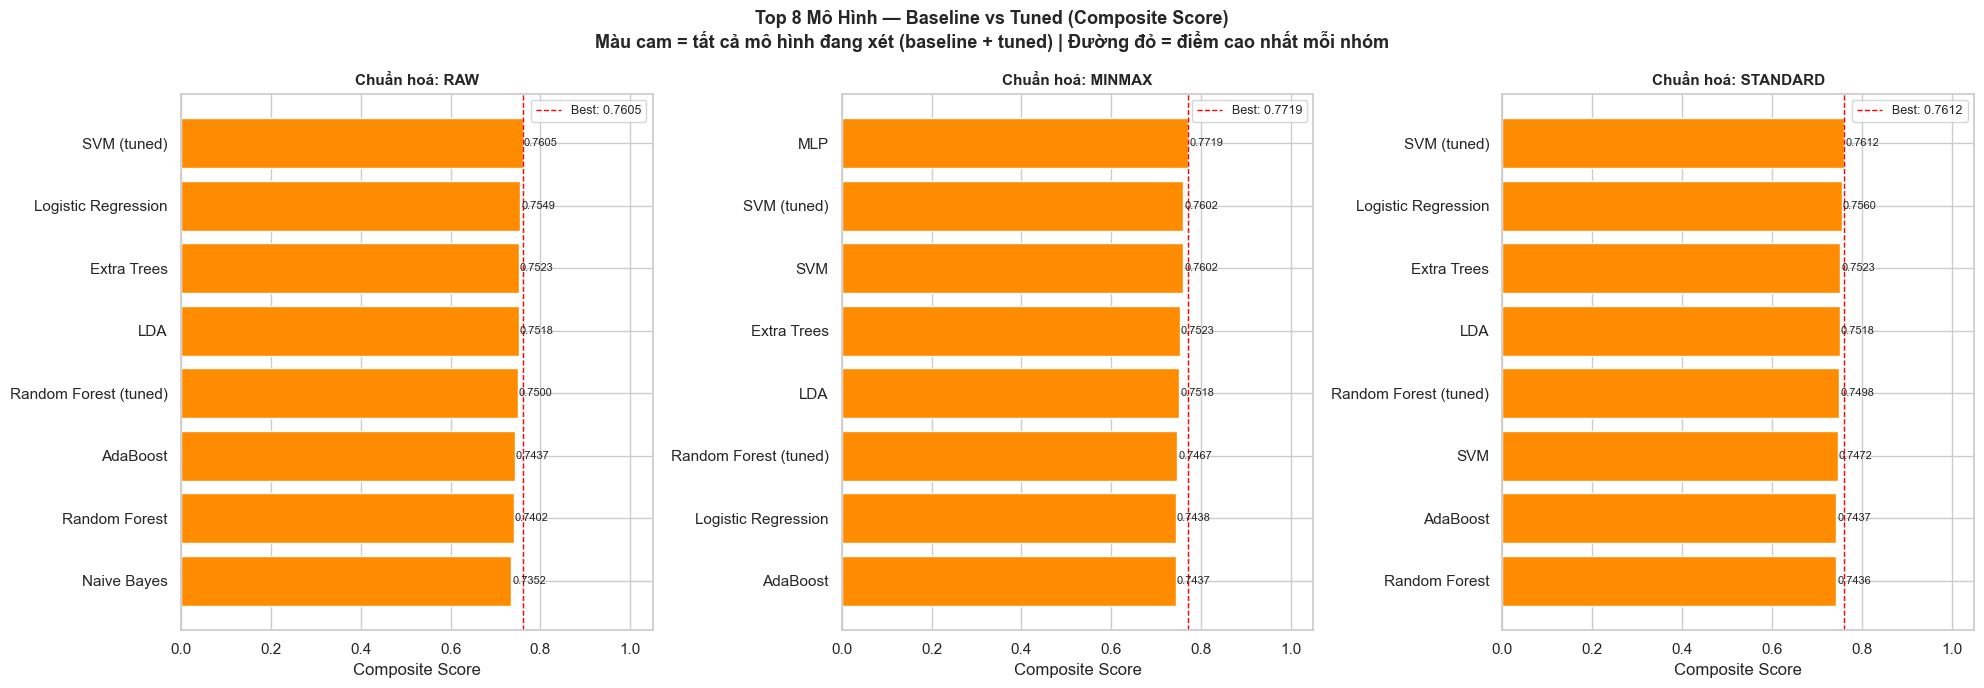

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharex=True)
fig.suptitle(
    'Top 8 Mô Hình — Baseline vs Tuned (Composite Score)\n'
    'Màu cam = tất cả mô hình đang xét (baseline + tuned) | Đường đỏ = điểm cao nhất mỗi nhóm',
    fontsize=13, fontweight='bold'
)
for i, scaler_name in enumerate(['raw', 'minmax', 'standard']):
    subset = df_all[df_all['Scaler'] == scaler_name].head(8).sort_values('Composite')
    bars = axes[i].barh(subset['Model'], subset['Composite'].fillna(0),
                        color='darkorange', edgecolor='white')
    axes[i].set_title(f'Chuẩn hoá: {scaler_name.upper()}', fontsize=11, fontweight='bold')
    axes[i].set_xlim(0.0, 1.05)
    axes[i].set_xlabel('Composite Score')
    axes[i].axvline(subset['Composite'].max(), color='red', linestyle='--', linewidth=1,
                    label=f'Best: {subset["Composite"].max():.4f}')
    axes[i].legend(fontsize=9)
    for bar, val in zip(bars, subset['Composite'].fillna(0)):
        axes[i].text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                     f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR, 'plot_baseline_vs_tuned.png'), bbox_inches='tight')
plt.show()


### 7.4. Chọn Top-2 Model, So Sánh và Lưu Best Model

Lấy 2 mô hình có Composite cao nhất từ `df_all`, so sánh trực tiếp các chỉ số CV của chúng.
Chỉ fit và lưu **1 file `best_model.pkl`** duy nhất — là model đứng đầu — để notebook test sử dụng.


In [6]:
# Lấy top-2 model theo Composite score
top2 = df_all.head(2).reset_index(drop=True)
print('TOP 2 MODEL (theo CV Composite score):')
display(top2[['Scaler', 'Model', 'Loại', 'Accuracy', 'Acc Std', 'F1', 'F1 Std', 'ROC_AUC', 'AUC Std', 'Composite', 'Params']])

# So sánh trực tiếp top-2
print('\nSo sánh Top-1 vs Top-2:')
m1, m2 = top2.iloc[0], top2.iloc[1]
cmp_df = pd.DataFrame({
    'Chỉ số':  ['Accuracy', 'Acc Std', 'F1', 'F1 Std', 'ROC_AUC', 'AUC Std', 'Composite', 'Scaler', 'Params'],
    m1['Model']: [m1['Accuracy'], m1['Acc Std'], m1['F1'], m1['F1 Std'], m1['ROC_AUC'], m1['AUC Std'], m1['Composite'], m1['Scaler'], m1['Params']],
    m2['Model']: [m2['Accuracy'], m2['Acc Std'], m2['F1'], m2['F1 Std'], m2['ROC_AUC'], m2['AUC Std'], m2['Composite'], m2['Scaler'], m2['Params']],
})
display(cmp_df)

# Chọn best = top-1
best_row    = m1.to_dict()
best_scaler = best_row['Scaler']
base_name   = best_row['Model'].replace(' (tuned)', '')

print(f'\n→ Best model: {best_row["Model"]} [{best_scaler}]')
print(f'  Composite: {best_row["Composite"]:.4f} | Acc: {best_row["Accuracy"]:.4f} | F1: {best_row["F1"]:.4f} | AUC: {best_row["ROC_AUC"]:.4f}')

# Lấy estimator — tuned thì dùng từ GridSearchCV, baseline thì fit 1 lần
train_df     = pd.read_csv(FILES[best_scaler][0])
X_train_full = train_df.iloc[:, :-1].values
y_train_full = train_df.iloc[:, -1].values

if '(tuned)' in best_row['Model'] and base_name in best_estimators.get(best_scaler, {}):
    best_model = best_estimators[best_scaler][base_name]
    print('Dùng tuned estimator từ GridSearchCV (không fit lại).')
else:
    best_model = dict(get_candidate_models())[base_name]
    best_model.fit(X_train_full, y_train_full)
    print('Fit baseline estimator trên toàn bộ tập train.')

# Lưu duy nhất 1 file best_model.pkl
with open(BEST_MODEL_PATH, 'wb') as f:
    pickle.dump({
        'model_name':  best_row['Model'],
        'scaler_name': best_scaler,
        'model':       best_model,
        'cv_metrics': {
            'Accuracy':  best_row.get('Accuracy'),
            'Acc Std':   best_row.get('Acc Std'),
            'F1':        best_row.get('F1'),
            'F1 Std':    best_row.get('F1 Std'),
            'ROC_AUC':   best_row.get('ROC_AUC'),
            'AUC Std':   best_row.get('AUC Std'),
            'Composite': best_row.get('Composite'),
            'Params':    best_row.get('Params'),
        },
        'top2_comparison': cmp_df.to_dict(orient='records'),
    }, f)

print(f'\nĐã lưu best model → {BEST_MODEL_PATH}')


TOP 2 MODEL (theo CV Composite score):


,Scaler,Model,Loại,Accuracy,Acc Std,F1,F1 Std,ROC_AUC,AUC Std,Composite,Params
0,minmax,MLP,Baseline,0.7953,0.0476,0.6857,0.0596,0.8270,0.0438,0.7719,default
1,standard,SVM (tuned),Tuned,0.7896,0.0287,0.6594,0.0436,0.8251,0.0397,0.7612,"{'C': 1, 'kernel': 'linear'}"



So sánh Top-1 vs Top-2:


,Chỉ số,MLP,SVM (tuned)
0,Accuracy,0.7953,0.7896
1,Acc Std,0.0476,0.0287
2,F1,0.6857,0.6594
3,F1 Std,0.0596,0.0436
4,ROC_AUC,0.827,0.8251
5,AUC Std,0.0438,0.0397
6,Composite,0.7719,0.7612
7,Scaler,minmax,standard
8,Params,default,"{'C': 1, 'kernel': 'linear'}"



→ Best model: MLP [minmax]
  Composite: 0.7719 | Acc: 0.7953 | F1: 0.6857 | AUC: 0.8270
Fit baseline estimator trên toàn bộ tập train.

Đã lưu best model → D:\final-project-CSTTNT-\indians-diabetes\model\pima_indians_diabetes\pima_indians_diabetes__best_model.pkl


## Bước 8: Ghi train_log.xlsx

Ghi log thực nghiệm vào Excel với 5 sheet theo đúng format mẫu:
- **Lich_su_chay** — lịch sử mỗi lần chạy (append vào nếu file đã tồn tại).
- **Baseline** — kết quả CV tất cả mô hình mặc định (có Std và Params).
- **Tuned** — kết quả CV sau GridSearchCV (có Std và Params đầy đủ).
- **Tat_ca_model** — bảng xếp hạng tổng hợp cả baseline và tuned.
- **Best_model** — chỉ số CV của model được chọn.


In [7]:
run_end = datetime.now()

summary_row = pd.DataFrame([{
    'Thời gian':   run_end.strftime('%Y-%m-%d %H:%M:%S'),
    'Dataset':     DATA_NAME,
    'K-Fold':      N_SPLITS,
    'Best model':  best_row['Model'],
    'Best scaler': best_scaler,
    'Accuracy':    best_row.get('Accuracy'),
    'F1':          best_row.get('F1'),
    'ROC_AUC':     best_row.get('ROC_AUC'),
    'Composite':   best_row.get('Composite'),
    'Model folder': MODEL_DIR,
}])

if os.path.exists(TRAIN_LOG):
    try:
        history = pd.concat(
            [pd.read_excel(TRAIN_LOG, sheet_name='Lich_su_chay'), summary_row],
            ignore_index=True
        )
    except Exception:
        history = summary_row
else:
    history = summary_row

best_model_sheet = pd.DataFrame([{
    'accuracy':  best_row.get('Accuracy'),
    'f1':        best_row.get('F1'),
    'roc_auc':   best_row.get('ROC_AUC'),
    'composite': best_row.get('Composite'),
}])

with pd.ExcelWriter(TRAIN_LOG, engine='openpyxl', mode='w') as writer:
    history.to_excel(writer,          sheet_name='Lich_su_chay', index=False)
    df_baseline.to_excel(writer,      sheet_name='Baseline',     index=False)
    df_tuned.to_excel(writer,         sheet_name='Tuned',        index=False)
    df_all.to_excel(writer,           sheet_name='Tat_ca_model', index=False)
    best_model_sheet.to_excel(writer, sheet_name='Best_model',   index=False)

print('=' * 70)
print('TỔNG KẾT TRAIN')
print('Best model :', best_row['Model'])
print('Best scaler:', best_scaler)
print('Train log  :', TRAIN_LOG)
print('Bước tiếp theo: chạy 03_test.ipynb')
print('=' * 70)


TỔNG KẾT TRAIN
Best model : MLP
Best scaler: minmax
Train log  : D:\final-project-CSTTNT-\indians-diabetes\exps_\pima_indians_diabetes\train_log.xlsx
Bước tiếp theo: chạy 03_test.ipynb
